### Importación de datos



In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



In [16]:
ingreso_tienda1 = tienda['Precio'].sum()
ingreso_tienda2 = tienda2['Precio'].sum()
ingreso_tienda3 = tienda3['Precio'].sum()
ingreso_tienda4 = tienda4['Precio'].sum()

print(f'Ingresos - Tienda 1: {ingreso_tienda1}')
print(f'Ingresos - Tienda 2: {ingreso_tienda2}')
print(f'Ingresos - Tienda 3: {ingreso_tienda3}')
print(f'Ingresos - Tienda 4: {ingreso_tienda4}')




Ingresos - Tienda 1: 1150880400.0
Ingresos - Tienda 2: 1116343500.0
Ingresos - Tienda 3: 1098019600.0
Ingresos - Tienda 4: 1038375700.0


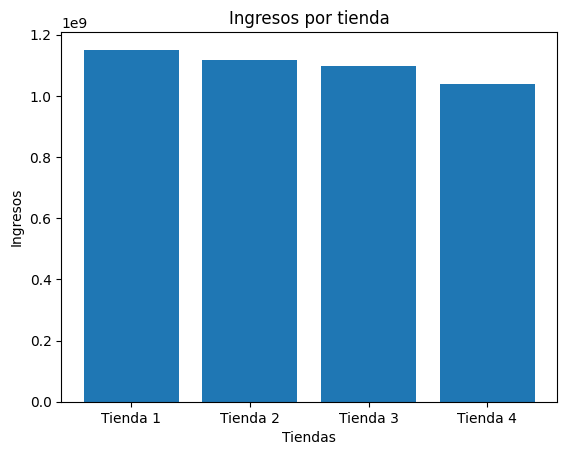

In [ ]:
import matplotlib.pyplot as plt
ingresos = {
    'Tienda 1': ingreso_tienda1,
    'Tienda 2': ingreso_tienda2,
    'Tienda 3': ingreso_tienda3,
    'Tienda 4': ingreso_tienda4
}
plt.bar(ingresos.keys(), ingresos.values())
plt.title('Ingresos por tienda')
plt.ylabel('Ingresos')
plt.xlabel('Tiendas')
plt.show()

# 2. Ventas por categoría

In [4]:
tienda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2359 entries, 0 to 2358
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Producto                2359 non-null   object 
 1   Categoría del Producto  2359 non-null   object 
 2   Precio                  2359 non-null   float64
 3   Costo de envío          2359 non-null   float64
 4   Fecha de Compra         2359 non-null   object 
 5   Vendedor                2359 non-null   object 
 6   Lugar de Compra         2359 non-null   object 
 7   Calificación            2359 non-null   int64  
 8   Método de pago          2359 non-null   object 
 9   Cantidad de cuotas      2359 non-null   int64  
 10  lat                     2359 non-null   float64
 11  lon                     2359 non-null   float64
dtypes: float64(4), int64(2), object(6)
memory usage: 221.3+ KB


In [5]:
tiendas = {
    'Tienda 1': tienda,
    'Tienda 2': tienda2,
    'Tienda 3': tienda3,
    'Tienda 4': tienda4
}


categoria_tienda1 = tienda.groupby('Categoría del Producto')['Producto'].count()
categoria_tienda2 = tienda2.groupby('Categoría del Producto')['Producto'].count()
categoria_tienda3 = tienda3.groupby('Categoría del Producto')['Producto'].count()
categoria_tienda4 = tienda4.groupby('Categoría del Producto')['Producto'].count()

for nombre, df in tiendas.items():
    print(f'\nVentas por categoría - {nombre}')
    print(df['Categoría del Producto'].value_counts())




Ventas por categoría - Tienda 1
Categoría del Producto
Muebles                    465
Electrónicos               448
Juguetes                   324
Electrodomésticos          312
Deportes y diversión       284
Instrumentos musicales     182
Libros                     173
Artículos para el hogar    171
Name: count, dtype: int64

Ventas por categoría - Tienda 2
Categoría del Producto
Muebles                    442
Electrónicos               422
Juguetes                   313
Electrodomésticos          305
Deportes y diversión       275
Instrumentos musicales     224
Libros                     197
Artículos para el hogar    181
Name: count, dtype: int64

Ventas por categoría - Tienda 3
Categoría del Producto
Muebles                    499
Electrónicos               451
Juguetes                   315
Electrodomésticos          278
Deportes y diversión       277
Libros                     185
Instrumentos musicales     177
Artículos para el hogar    177
Name: count, dtype: int64

Ventas po

# 3. Calificación promedio de la tienda


In [6]:
promedio_t1 = tienda['Calificación'].mean()
promedio_t2 = tienda2['Calificación'].mean()
promedio_t3 = tienda3['Calificación'].mean()
promedio_t4 = tienda4['Calificación'].mean()

promedios = {
    'Tienda 1': round(float(tienda['Calificación'].mean()), 2),
    'Tienda 2': round(float(tienda2['Calificación'].mean()), 2),
    'Tienda 3': round(float(tienda3['Calificación'].mean()), 2),
    'Tienda 4': round(float(tienda4['Calificación'].mean()), 2)
}

print(promedios)


{'Tienda 1': 3.98, 'Tienda 2': 4.04, 'Tienda 3': 4.05, 'Tienda 4': 4.0}


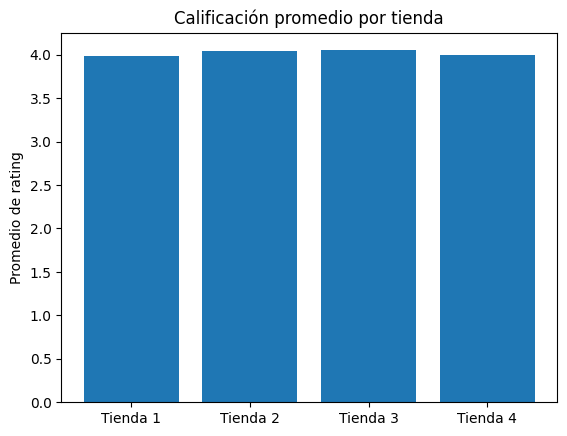

In [7]:
plt.bar(promedios.keys(), promedios.values())
plt.title('Calificación promedio por tienda')
plt.ylabel('Promedio de rating')
plt.show()

# 4. Productos más y menos vendidos

In [8]:
ventas_t1 = tienda['Producto'].value_counts()

mas_vendido_t1 = ventas_t1.idxmax()
menos_vendido_t1 = ventas_t1.idxmin()
print('Ventas por producto - Tienda 1')
print("Más vendido:", mas_vendido_t1)
print("Menos vendido:", menos_vendido_t1)

ventas_t2 = tienda2['Producto'].value_counts()

mas_vendido_t2 = ventas_t2.idxmax()
menos_vendido_t2 = ventas_t2.idxmin()
print('Ventas por producto - Tienda 2')
print("Más vendido:", mas_vendido_t2)
print("Menos vendido:", menos_vendido_t2)

ventas_t3 = tienda3['Producto'].value_counts()
mas_vendido_t3 = ventas_t3.idxmax()
menos_vendido_t3 = ventas_t3.idxmin()
print('Ventas por producto - Tienda 3')
print("Más vendido:", mas_vendido_t3)
print("Menos vendido:", menos_vendido_t3)

ventas_t4 = tienda4['Producto'].value_counts()
mas_vendido_t4 = ventas_t4.idxmax()
menos_vendido_t4 = ventas_t4.idxmin()
print('Ventas por producto - Tienda 4')
print("Más vendido:", mas_vendido_t4)
print("Menos vendido:", menos_vendido_t4)   

Ventas por producto - Tienda 1
Más vendido: Microondas
Menos vendido: Auriculares con micrófono
Ventas por producto - Tienda 2
Más vendido: Iniciando en programación
Menos vendido: Juego de mesa
Ventas por producto - Tienda 3
Más vendido: Kit de bancas
Menos vendido: Bloques de construcción
Ventas por producto - Tienda 4
Más vendido: Cama box
Menos vendido: Guitarra eléctrica


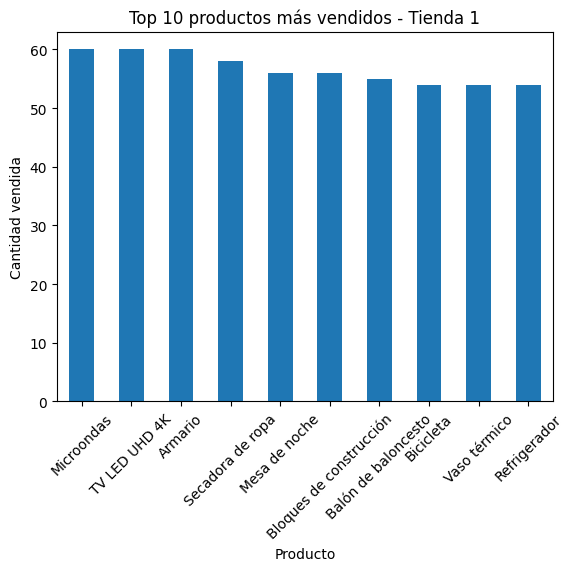

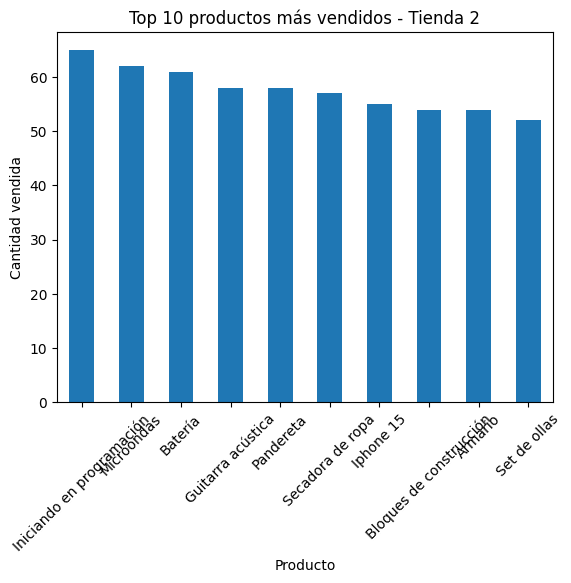

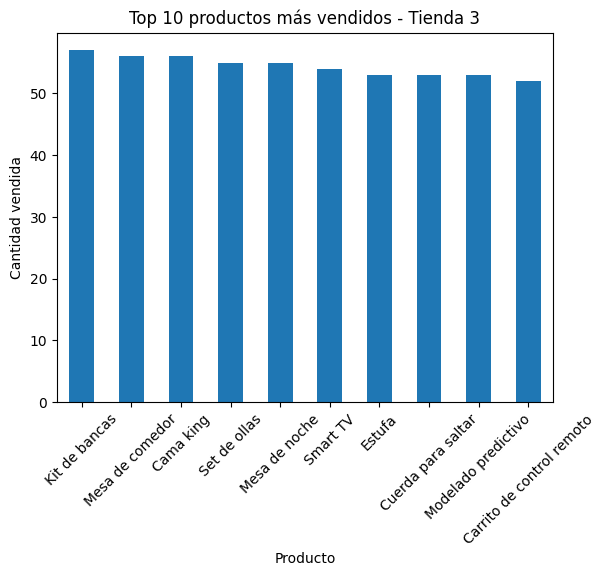

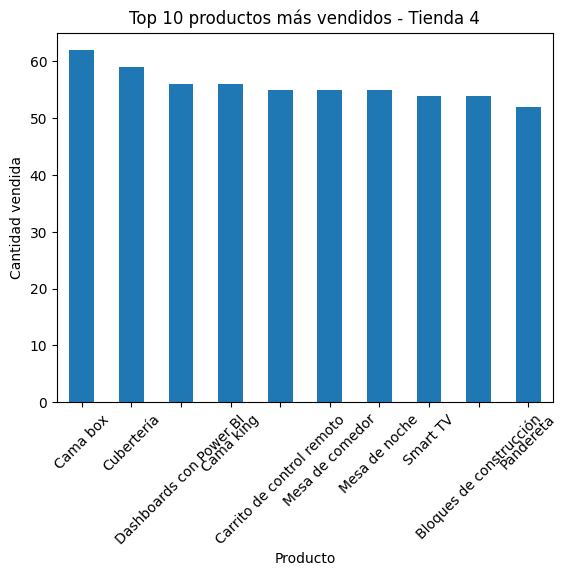

In [9]:
import matplotlib.pyplot as plt

tiendas = {
    'Tienda 1': tienda,
    'Tienda 2': tienda2,
    'Tienda 3': tienda3,
    'Tienda 4': tienda4
}

for nombre, df in tiendas.items():

    ventas = df['Producto'].value_counts().head(10)

    ventas.plot(kind='bar')

    plt.title(f'Top 10 productos más vendidos - {nombre}')
    plt.xlabel('Producto')
    plt.ylabel('Cantidad vendida')
    plt.xticks(rotation=45)
    plt.show()

# 5. Envío promedio por tienda

In [ ]:
envio_t1 = tienda['Costo de envío'].mean()
envio_t2 = tienda2['Costo de envío'].mean()
envio_t3 = tienda3['Costo de envío'].mean()
envio_t4 = tienda4['Costo de envío'].mean()


print(f'Costo de envío promedio - Tienda 1: {envio_t1:.2f}')
print(f'Costo de envío promedio - Tienda 2: {envio_t2:.2f}')
print(f'Costo de envío promedio - Tienda 3: {envio_t3:.2f}')
print(f'Costo de envío promedio - Tienda 4: {envio_t4:.2f}')


print(envios)

Costo de envío promedio - Tienda 1: 26018.61
Costo de envío promedio - Tienda 2: 25216.24
Costo de envío promedio - Tienda 3: 24805.68
Costo de envío promedio - Tienda 4: 23459.46


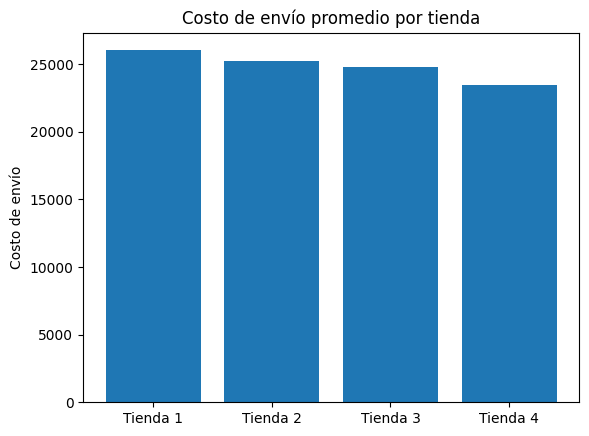

In [13]:
envios = {
    'Tienda 1': round(float(envio_t1), 2),
    'Tienda 2': round(float(envio_t2), 2),
    'Tienda 3': round(float(envio_t3), 2),
    'Tienda 4': round(float(envio_t4), 2)
}
plt.bar(envios.keys(), envios.values())
plt.title('Costo de envío promedio por tienda')
plt.ylabel('Costo de envío')
plt.show()

### **CONCLUSION**
    Después de analizar los datos de las cuatro tiendas donde se evaluaron métricas como ingresos totales, calificaciones promedio de los clientes, productos más vendidos y costo promedio de envío.
    Los resultados muestran que la Tienda 4 presenta los ingresos más bajos entre todas las tiendas, lo que indica un menor rendimiento en ventas. Aunque su calificación promedio es aceptable, no lidera ninguna metrica.
    Por esta razón, se recomienda que el Sr. João considere vender la Tienda 4, ya que su desempeño general es el más bajo en comparación con las otras tiendas de la cadena.